#### Data And Library Import

In [16]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [19]:
# Download 5 years of Apple stock data
df = yf.download("AAPL", period="5y")

# Display the first five rows
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-07-14,145.384216,145.793625,143.951330,144.360739,127050800
2021-07-15,144.731171,146.212798,143.376266,145.471992,106820300
2021-07-16,142.693924,145.978833,142.196806,144.711667,93251400
2021-07-19,138.853394,140.432502,138.093088,140.120574,121434600
2021-07-20,142.459991,143.386018,139.350545,139.837921,96350000


#### Data Cleaning

In [20]:
#removing multiindex
df.columns = df.columns.droplevel(1)

In [22]:
#display first 5 row and column
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-07-14,145.384216,145.793625,143.951330,144.360739,127050800
2021-07-15,144.731171,146.212798,143.376266,145.471992,106820300
2021-07-16,142.693924,145.978833,142.196806,144.711667,93251400
2021-07-19,138.853394,140.432502,138.093088,140.120574,121434600
2021-07-20,142.459991,143.386018,139.350545,139.837921,96350000


In [23]:
#removing column name(price)
df.columns.name = None

In [25]:
# converting the index(date) to regular column
df.reset_index(inplace=True)

In [26]:
#displays first 5 rows
df.head()

,Date,Close,High,Low,Open,Volume
0,2021-07-14,145.384216,145.793625,143.951330,144.360739,127050800
1,2021-07-15,144.731171,146.212798,143.376266,145.471992,106820300
2,2021-07-16,142.693924,145.978833,142.196806,144.711667,93251400
3,2021-07-19,138.853394,140.432502,138.093088,140.120574,121434600
4,2021-07-20,142.459991,143.386018,139.350545,139.837921,96350000


In [27]:
#Inspect Dataset Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1254 non-null   datetime64[ns]
 1   Close   1254 non-null   float64       
 2   High    1254 non-null   float64       
 3   Low     1254 non-null   float64       
 4   Open    1254 non-null   float64       
 5   Volume  1254 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 58.9 KB


In [28]:
#checking for duplicate
df.duplicated().sum()

np.int64(0)

#### Sorting And Filtering

In [29]:
# Filtering Data
# for rows where closing price is above $150 with volum more than 70000000

df[(df["Close"] > 150) & (df["Volume"] > 70000000)]

,Date,Close,High,Low,Open,Volume
38,2021-09-07,152.962723,153.519156,150.717431,151.283636,82278300
39,2021-09-08,151.420288,153.304371,150.317163,153.245800,74420200
89,2021-11-17,150.057541,151.533768,147.613448,147.623219,88807000
90,2021-11-18,154.339584,155.121697,149.627381,150.272625,137827700
91,2021-11-19,156.959641,157.419131,153.029535,154.124484,117305600
...,...,...,...,...,...,...
1231,2026-06-09,290.549988,300.750000,287.779999,300.279999,70108800
1238,2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200
1242,2026-06-25,275.149994,288.799988,273.750000,287.399994,107013700
1243,2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500


In [30]:
#sorting values base on highest volum
df.sort_values("Volume", ascending=False)

,Date,Close,High,Low,Open,Volume
802,2024-09-20,226.502090,231.355706,225.926404,228.258925,318679900
1243,2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500
739,2024-06-21,205.708069,210.070275,205.331327,208.583157,241805100
733,2024-06-12,211.240143,218.308899,205.123118,205.589083,198134300
110,2021-12-17,167.312805,169.590701,165.895234,166.129858,195432700
...,...,...,...,...,...,...
868,2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700
1121,2025-12-30,272.573578,273.571723,271.775074,272.304090,22139600
1119,2025-12-26,272.892975,274.859323,272.353968,273.651575,21521800
1100,2025-11-28,278.332886,278.482601,275.478174,276.745838,20135600


#### Grouping And Aggregation

In [42]:
# YEAR COLUMN
df["Year"] = df["Date"].dt.year

#display the year column
df["Year"].head()

0    2021
1    2021
2    2021
3    2021
4    2021
Name: Year, dtype: int32

In [33]:
#AVG Close Price
df.groupby("Year")["Close"].mean()

Year
2021    149.686082
2022    151.805449
2023    170.194612
2024    205.457393
2025    231.349891
2026    275.349043
Name: Close, dtype: float64

In [34]:
# Max Close Price
df.groupby("Year")["Close"].max()

Year
2021    176.297302
2022    177.939713
2023    195.892609
2024    257.375580
2025    285.659271
2026    317.309998
Name: Close, dtype: float64

In [35]:
# Calculate yearly average, highest, and lowest closing prices, 
# and average trading volume
df.groupby("Year").agg({
    "Close":["mean","max","min"],
    "Volume":"mean"
})

Close                                Volume
            mean         max         min          mean
Year                                                  
2021  149.686082  176.297302  135.830215  8.460219e+07
2022  151.805449  177.939713  123.936523  8.791038e+07
2023  170.194612  195.892609  122.933548  5.922355e+07
2024  205.457393  257.375580  163.361389  5.710678e+07
2025  231.349891  285.659271  171.513763  5.417578e+07
2026  275.349043  317.309998  246.242508  5.042366e+07

#### Creating Calculated Columns

In [55]:
# daily price change
df["Price_Change"] = df["Close"] - df["Open"]

In [56]:
# percentage change
df["Percent_Change"] = (
    (df["Close"] - df["Open"]) / df["Open"]
) * 100

In [57]:
# daily trading range
df["Trading_Range"] = df["High"] - df["Low"]

#### Data Formation And Restructuring

In [59]:
#formating volum datatype to int
df["Volume"] = df["Volume"].astype(int)

In [58]:
#round price to 2 decimal places
df = df.round(2)

In [70]:
# data restructuring 
df = df[[
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]].copy()

In [71]:
# display of first 5 rows
df.head()

,Date,Open,High,Low,Close,Volume
0,2021-07-14,144.36,145.79,143.95,145.38,127050800
1,2021-07-15,145.47,146.21,143.38,144.73,106820300
2,2021-07-16,144.71,145.98,142.20,142.69,93251400
3,2021-07-19,140.12,140.43,138.09,138.85,121434600
4,2021-07-20,139.84,143.39,139.35,142.46,96350000


In [72]:
# Export the cleaned DataFrame to a CSV file
df.to_csv("AAPL_cleaned.csv", index=True)

#### Date Manipulation And Trend Analysis

In [73]:
#date manipulation

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Weekday"] = df["Date"].dt.day_name()
df["Quarter"] = df["Date"].dt.quarter

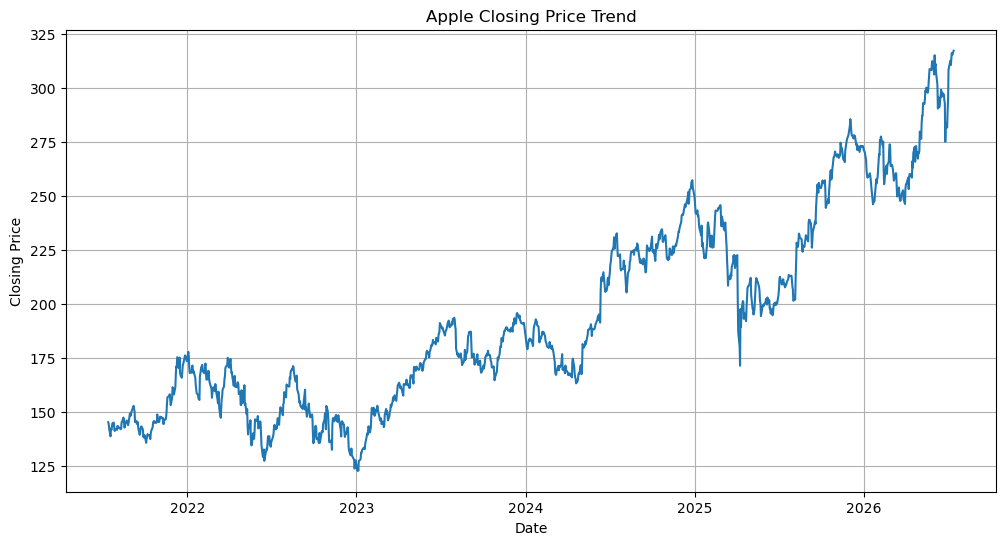

In [105]:
# trend analysis
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"])
plt.title("Apple Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

#### Daily And Monthly Analysis

In [75]:
#daily and monthly performance analysis
df["Daily_Return"] = df["Close"].pct_change() * 100


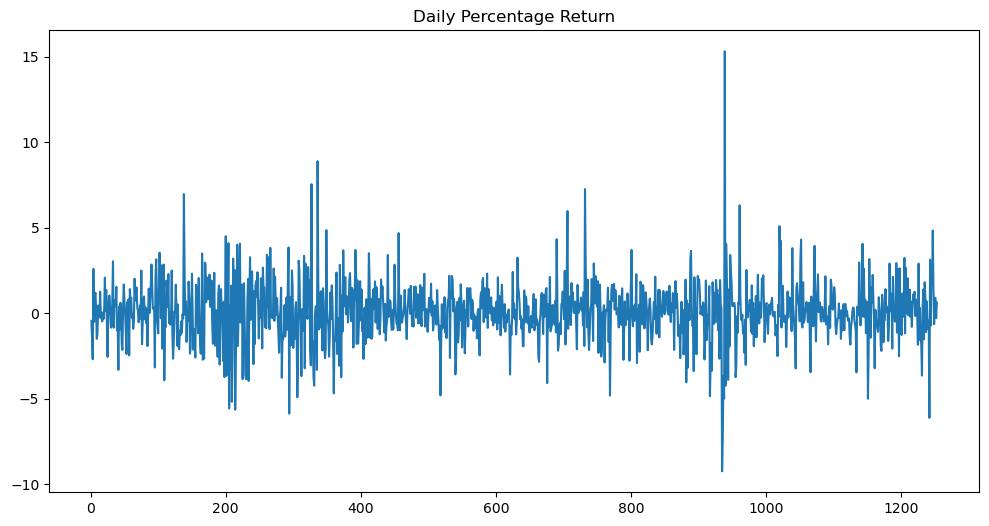

In [77]:
#visual for the daily percentage return of Apple stock over time
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Daily_Return"])
plt.title("Daily Percentage Return")
plt.show()

In [80]:
# Calculate the average monthly closing price

monthly_close = (
    df.groupby(pd.Grouper(key="Date", freq="ME"))["Close"]
      .mean()
      .reset_index()
)

monthly_close.head()

,Date,Close
0,2021-07-31,142.883846
1,2021-08-31,144.614545
2,2021-09-30,144.778571
3,2021-10-31,142.100000
4,2021-11-30,150.766190


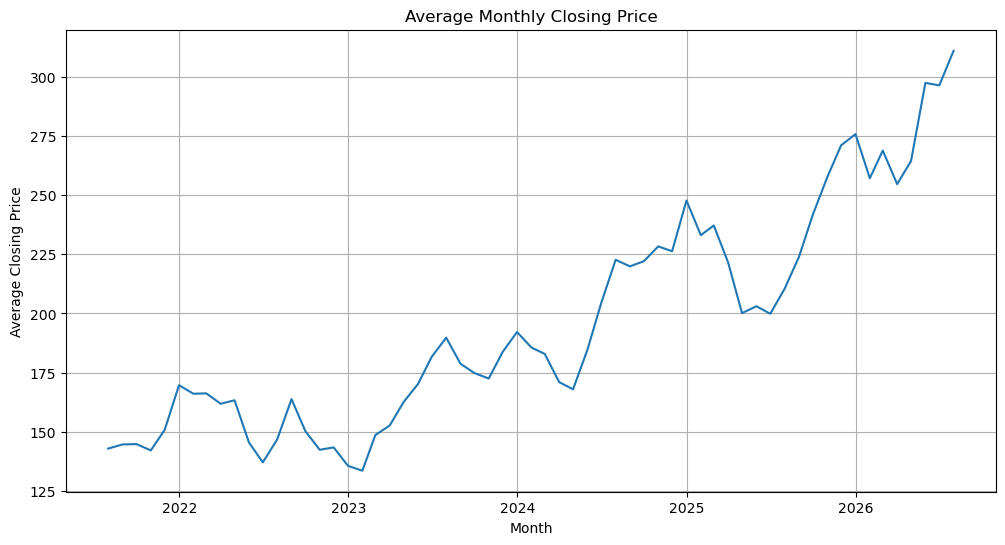

In [81]:

# Visual of the average monthly closing price

plt.figure(figsize=(12,6))

plt.plot(monthly_close["Date"], monthly_close["Close"])

plt.title("Average Monthly Closing Price")
plt.xlabel("Month")
plt.ylabel("Average Closing Price")

plt.grid(True)

plt.show()

#### Rolling Averages

In [85]:
# 7 days moving avg
df["MA_7"] = df["Close"].rolling(window=7).mean()

In [86]:
# 30 days moving avg
df["MA_30"] = df["Close"].rolling(window=30).mean()

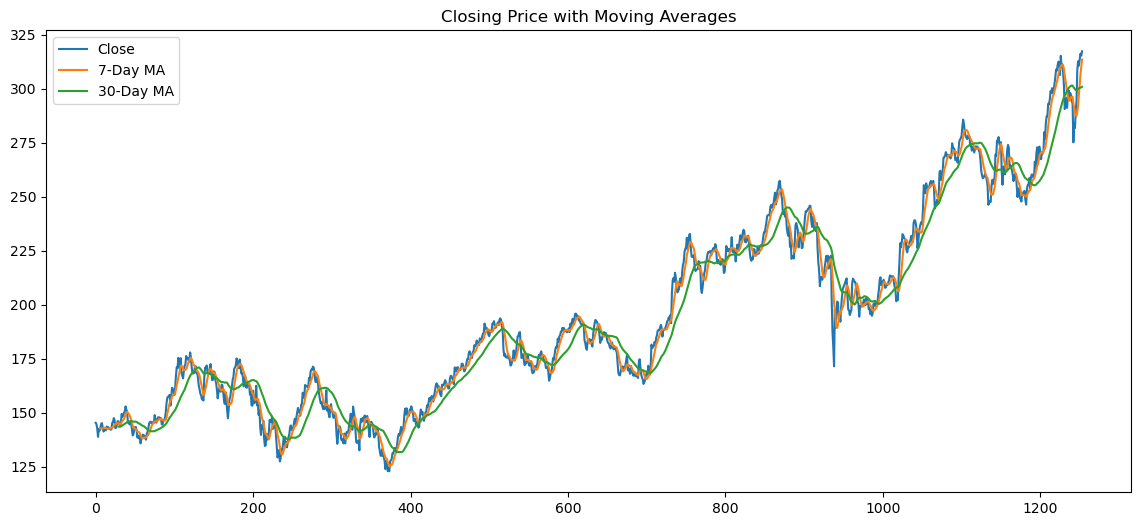

In [87]:

plt.figure(figsize=(14,6))

plt.plot(df.index, df["Close"], label="Close")
plt.plot(df.index, df["MA_7"], label="7-Day MA")
plt.plot(df.index, df["MA_30"], label="30-Day MA")

plt.legend()
plt.title("Closing Price with Moving Averages")
plt.show()

#### Percentage Change Analysis

In [88]:
# Calculate the daily percentage return

df["Daily_Return"] = df["Close"].pct_change() * 100
# display first 5 rows
df[["Date", "Daily_Return"]].head()

,Date,Daily_Return
0,2021-07-14,NaN
1,2021-07-15,-0.447104
2,2021-07-16,-1.409521
3,2021-07-19,-2.691149
4,2021-07-20,2.599928


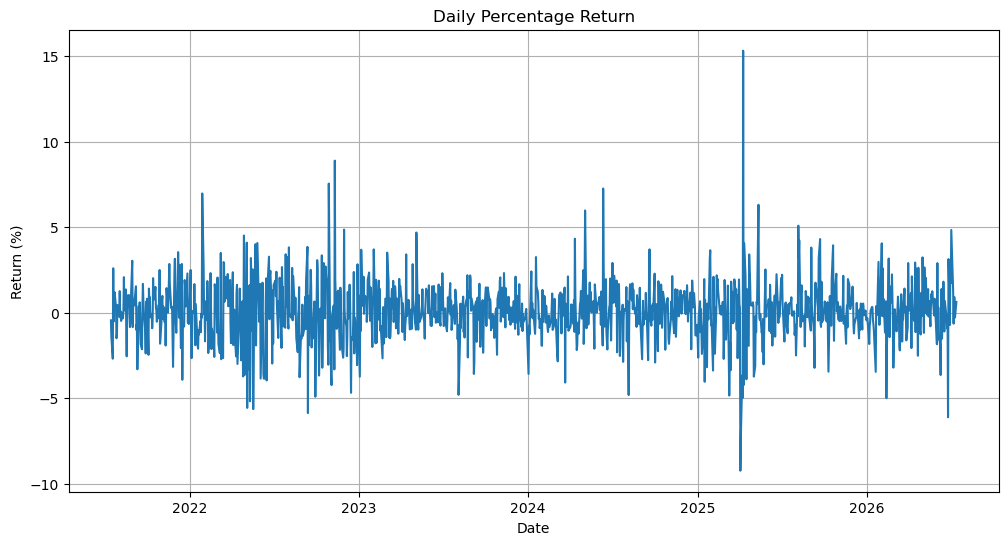

In [89]:
# Visual of the daily percentage return

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Daily_Return"])

plt.title("Daily Percentage Return")
plt.xlabel("Date")
plt.ylabel("Return (%)")

plt.grid(True)

plt.show()

#### Time-Based Visuals

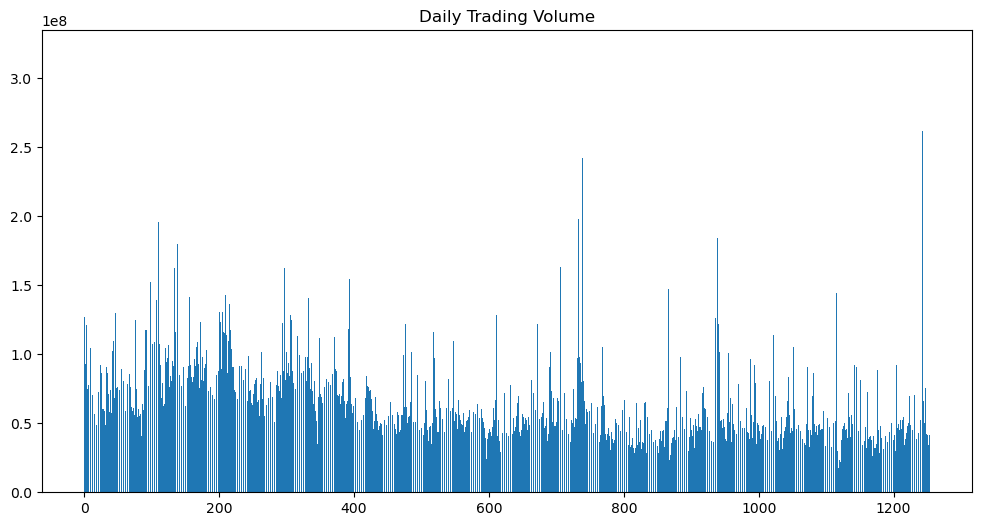

In [101]:
# visualize the trading volume of AAPL stock
plt.figure(figsize=(12,6))
plt.bar(df.index, df["Volume"])
plt.title("Daily Trading Volume")
plt.show()

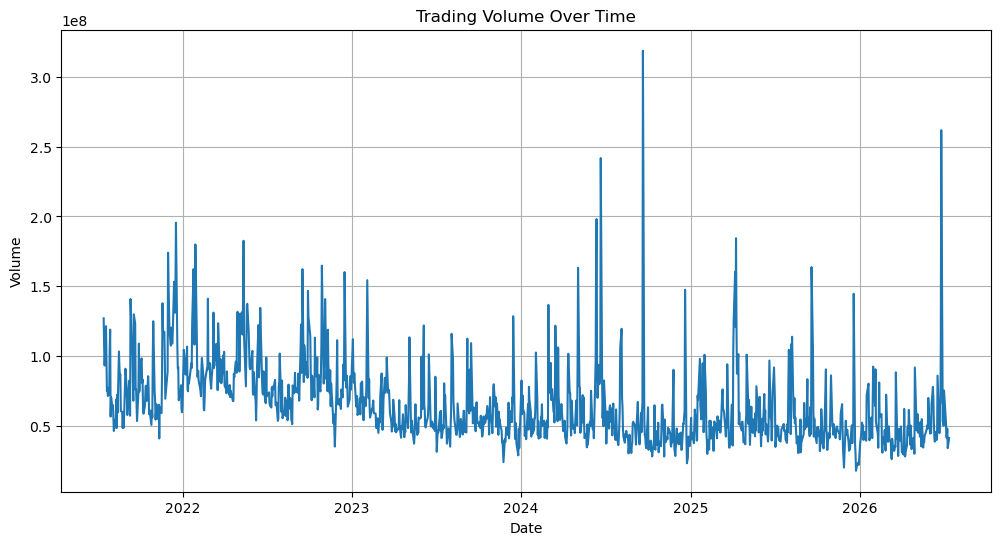

In [102]:
# Plot the trading volume over time

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Volume"])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)

plt.show()

#### Feature Engineering

In [92]:
#daily price change
df["Daily_Price_Change"] = df["Close"] - df["Open"]

In [93]:
#percentage price chnge
df["Percentage_Price_Change"] = (
    (df["Close"] - df["Open"]) / df["Open"]
) * 100

In [94]:
#7 days moving avg
df["MA_7"] = df["Close"].rolling(window=7).mean()

In [95]:
#30 days moving average
df["MA_30"] = df["Close"].rolling(window=30).mean()

In [96]:
#monthly returns
df["Monthly_Return"] = df["Close"].pct_change(periods=21) * 100

In [97]:
#30 days volatility measures
df["Volatility_30"] = (
    df["Daily_Return"]
    .rolling(window=30)
    .std()
)

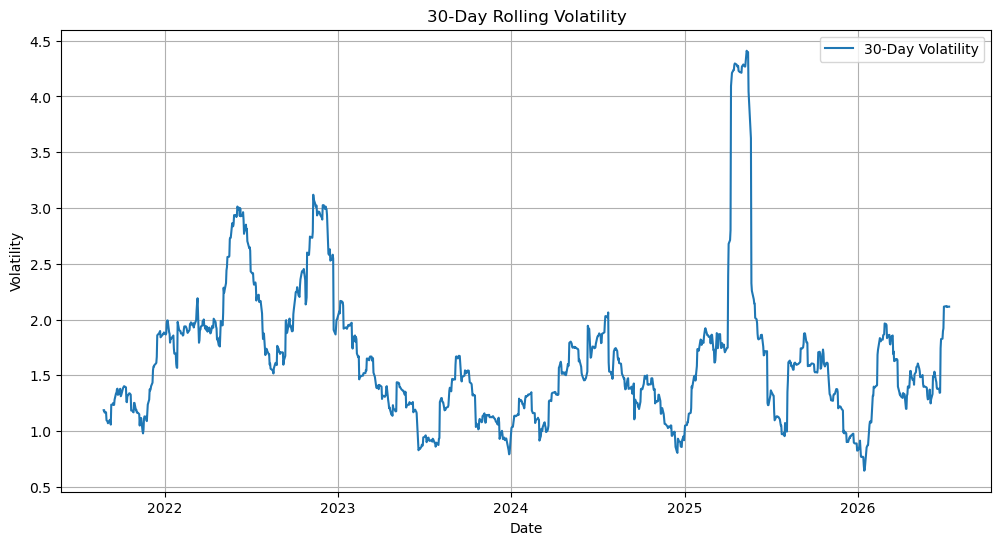

In [107]:
# Visualize the 30-day rolling volatility

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Volatility_30"], label="30-Day Volatility")

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.legend()
plt.grid(True)

plt.show()

In [98]:
#price range
df["Price_Range"] = df["High"] - df["Low"]

In [99]:
df.head()

,Date,Open,High,Low,Close,Volume,Year,Month,Weekday,Quarter,Daily_Return,MA_7,MA_30,Daily_Price_Change,Percentage_Price_Change,Monthly_Return,Volatility_30,Price_Range
0,2021-07-14,144.36,145.79,143.95,145.38,127050800,2021,7,Wednesday,3,NaN,NaN,NaN,1.02,0.706567,NaN,NaN,1.84
1,2021-07-15,145.47,146.21,143.38,144.73,106820300,2021,7,Thursday,3,-0.447104,NaN,NaN,-0.74,-0.508696,NaN,NaN,2.83
2,2021-07-16,144.71,145.98,142.20,142.69,93251400,2021,7,Friday,3,-1.409521,NaN,NaN,-2.02,-1.395895,NaN,NaN,3.78
3,2021-07-19,140.12,140.43,138.09,138.85,121434600,2021,7,Monday,3,-2.691149,NaN,NaN,-1.27,-0.906366,NaN,NaN,2.34
4,2021-07-20,139.84,143.39,139.35,142.46,96350000,2021,7,Tuesday,3,2.599928,NaN,NaN,2.62,1.873570,NaN,NaN,4.04
